#### One-Class SVM

1.  One Class SVM is an unsupervised machine learning anamoly based algorithms which is used to detect the anamolies or unusual patterns from the data.

2.  It learns all the patterns of the normal data only and detects the anamolies which are different from the learned data.


#### Applications of One Class SVM:-------

(a.) Fraud detection


#### Problem Statement:--------

1.  Built a Anamoly Detection System using Isolation Forest on a creditcard transaction dataset and identify the fraudulent credit card transactions.


####  Project Workflow :-----------------

1.	Import Libraries

2.	Load Dataset

3.	Exploratory Data Analysis

4.	Data Preprocessing

5.	Train-Test Split

6.	Feature Scaling

7.	Train One-Class SVM

8.	Make Predictions

9.	Model Evaluation

10.	Visualization

11.	Conclusion


#### Step 1: Import all the necessary libraries

In [2635]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection import  train_test_split
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.svm             import  OneClassSVM
from    sklearn.metrics         import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

#### Step 2: Load the dataset

In [2636]:
#### load the dataset

df = pd.read_csv("creditcard.csv")

In [2637]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### OBSERVATIONS:

1.  The independent features of this dataset ranges from Time ........ Amount.

2.  The dependent   feature of this dataset is target/class.

    (a.)    If the Class is 0 =============================>  Normal Transactions

    (b.)    If the Class is 1 =============================>  Fraud  Transactions.

#### Step 3: Perform the Data Exploration

In [2638]:
#### get the top five records in the dataset

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2639]:
#### get the last five records in the dataset

df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [2640]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 284807


In [2641]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (284807, 31)


In [2642]:
#### get the columns used in the dataset

df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [2643]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

#### OBSERVATIONS:

1.  All the independent features are floating in nature.

2.  But the target or the dependent feature is integer in nature.

In [2644]:
#### Count the catgeories in the "Class" column

df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#### OBSERVATIONS:

1.  From the above table we can see that there are 

    (a.)    284315 normal transactions.

    (b.)    492    fraud transactions.

2.  As the number of normal transactions are much higher than the number of fraud transactions, so it is a highly imbalanced dataset.

In [2645]:
#### get the descriptive statistical summary about all the columns used in the dataset

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


#### OBSERVATIONS:

1.  The above table depicts about the information of the statistical summary for each numerical column used in the dataset.

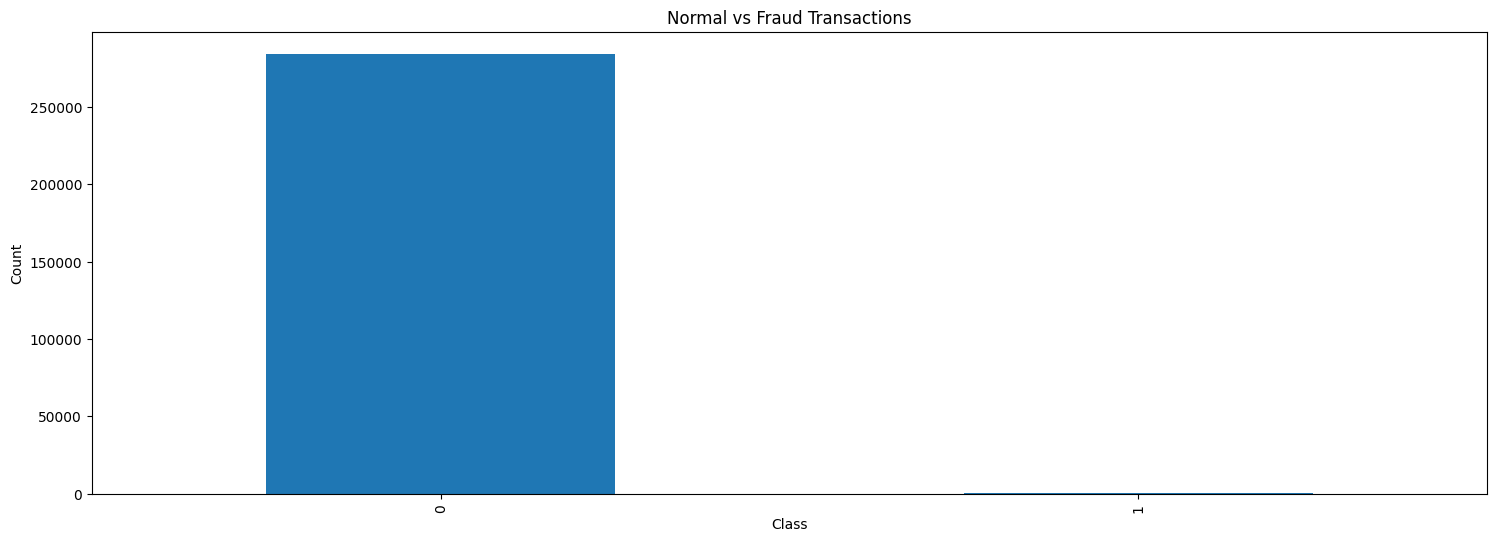

In [2646]:
#### Plot the graph for Normal vs Fraud Transactions

plt.figure(figsize=(18,6))

df['Class'].value_counts().plot(kind='bar')

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

#### OBSERVATIONS:

1.  From the above table we can see that there are 

    (a.)    284315 normal transactions.

    (b.)    492    fraud transactions.

2.  As the number of normal transactions are much higher than the number of fraud transactions, so it is a highly imbalanced dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [2647]:
#### Perform Downsampling on the Majority class of theb target variable so as to make it a balanced dataset

##### Keep both the normal transactions and fraud transactions in a seperate dataframe

normal = df[df['Class']==0]

fraud = df[df['Class']==1]

In [2648]:
normal

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [2649]:
fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [2650]:
#### perform downsampling on the normal class

from    sklearn.utils   import  resample

normal_downsampled = resample(
    normal                              ,
    random_state    =           42      ,
    n_samples       =         len(fraud)  
)

In [2651]:
normal_downsampled

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
122207,76475.0,-1.004046,1.053270,1.093808,-0.591014,0.516087,-0.415980,0.476134,0.305124,-0.844857,...,-0.198036,-0.798085,-0.105299,-0.624258,-0.033219,-0.054535,-0.066880,0.004584,14.95,0
147150,88181.0,-0.422831,0.239428,1.512375,-1.075881,-0.809157,-0.089498,0.838381,-0.463100,-0.698558,...,-0.568205,-0.860065,-0.002557,-0.079295,-0.594139,-0.644110,-0.140223,-0.106076,123.75,0
132194,79893.0,-0.138855,-0.976921,0.883736,-3.393556,1.142488,3.914621,-1.119220,0.869570,-1.539373,...,-0.228985,-0.147826,-0.093426,0.977747,-0.269920,-0.413884,0.018587,-0.078387,20.00,0
259649,159214.0,0.256621,0.223809,0.975735,-0.220988,-0.270464,0.568080,-0.394989,-0.637367,0.416232,...,1.080174,0.763228,-0.220929,0.824970,0.789579,-0.064883,0.223809,0.257101,39.95,0
120126,75718.0,-1.438013,1.298178,0.909734,-0.495798,0.255640,-0.766527,0.449792,0.361424,-0.492433,...,-0.141175,-0.479615,0.105791,0.038759,-0.299486,-0.087374,-0.033205,0.108152,4.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273800,165706.0,2.341158,-1.140193,-1.431234,-1.446218,-0.959278,-1.328559,-0.580484,-0.525896,-1.617138,...,0.204313,1.250873,-0.096074,0.132532,0.408741,0.286812,-0.011742,-0.067825,13.99,0
9384,13744.0,-0.300059,0.364418,1.611098,-1.056658,0.652460,0.112808,0.338364,-0.154589,1.126379,...,-0.051844,0.166848,-0.294988,-0.818076,0.005634,0.907665,-0.267201,-0.249516,20.33,0
38205,39293.0,0.813744,-0.617420,1.782595,1.696710,-1.515473,0.350754,-0.893978,0.316722,1.186037,...,0.305272,0.919456,-0.114790,0.653273,0.272301,-0.189475,0.091363,0.064843,125.53,0
74642,55681.0,-1.833329,0.046103,2.151713,-0.431903,-0.762017,-0.388451,-0.215207,0.714157,-0.162439,...,0.310683,0.559447,-0.071901,0.598248,0.370825,0.617409,0.112006,-0.033303,101.16,0


In [2652]:
#### Combine both the fraud and the downsampled normal data

df_new = pd.concat([normal_downsampled, fraud])

In [2653]:
df_new

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
122207,76475.0,-1.004046,1.053270,1.093808,-0.591014,0.516087,-0.415980,0.476134,0.305124,-0.844857,...,-0.198036,-0.798085,-0.105299,-0.624258,-0.033219,-0.054535,-0.066880,0.004584,14.95,0
147150,88181.0,-0.422831,0.239428,1.512375,-1.075881,-0.809157,-0.089498,0.838381,-0.463100,-0.698558,...,-0.568205,-0.860065,-0.002557,-0.079295,-0.594139,-0.644110,-0.140223,-0.106076,123.75,0
132194,79893.0,-0.138855,-0.976921,0.883736,-3.393556,1.142488,3.914621,-1.119220,0.869570,-1.539373,...,-0.228985,-0.147826,-0.093426,0.977747,-0.269920,-0.413884,0.018587,-0.078387,20.00,0
259649,159214.0,0.256621,0.223809,0.975735,-0.220988,-0.270464,0.568080,-0.394989,-0.637367,0.416232,...,1.080174,0.763228,-0.220929,0.824970,0.789579,-0.064883,0.223809,0.257101,39.95,0
120126,75718.0,-1.438013,1.298178,0.909734,-0.495798,0.255640,-0.766527,0.449792,0.361424,-0.492433,...,-0.141175,-0.479615,0.105791,0.038759,-0.299486,-0.087374,-0.033205,0.108152,4.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [2654]:
#### Check the count of all the categories in the Class column in the new dataset

df_new['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

#### OBSERVATIONS:

1.  Now the dtaset is completely balanced as it has

    (a.)    492 normal  transactions

    (b.)    492 fraud   transactions

In [2655]:
#### get the length of the revised dataset

print("Length of the revised dataset is:", len(df_new))

Length of the revised dataset is: 984


In [2656]:
#### get the shape of the revised dataset

print("Shape of the revised dataset is:", df_new.shape)

Shape of the revised dataset is: (984, 31)


In [2657]:
#### To check for the duplicate records in the dataset

df_new[df_new.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102443,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102444,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102445,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102446,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
141258,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,...,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141260,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1
143334,85285.0,-7.030308,3.421991,-9.525072,5.270891,-4.024630,-2.865682,-6.989195,3.791551,-4.622730,...,1.103398,-0.541855,0.036943,-0.355519,0.353634,1.042458,1.359516,-0.272188,0.00,1
143336,85285.0,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,-4.684952,...,0.954272,-0.451086,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,252.92,1
150661,93853.0,-6.185857,7.102985,-13.030455,8.010823,-7.885237,-3.974550,-12.229608,4.971232,-4.248307,...,2.502772,0.481691,0.480958,0.360319,-0.293354,-0.199193,-0.203917,0.398927,44.90,1


#### OBSERVATIONS:

1.  There are 19 duplicate records in the dataset. So remove them.

In [2658]:
#### Drop the duplicates

df_new = df_new.drop_duplicates()

In [2659]:
#### To again check for the duplicate records in the dataset

df_new[df_new.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [2660]:
#### To check for the NULL records in the revised dataset

df_new.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

#### Step 5: Perform Exploratory Data Analysis

In [2661]:
df_new['Class'].value_counts()

Class
0    492
1    473
Name: count, dtype: int64

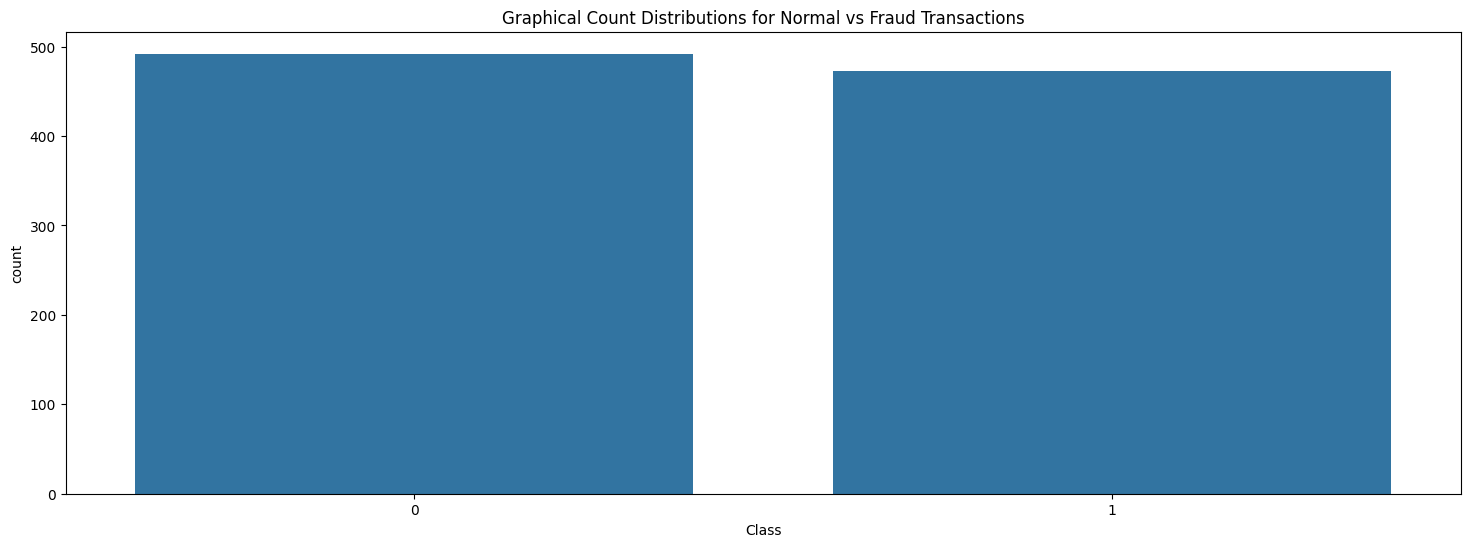

In [2662]:
### Perform the graphical distribution for Normal vs Fraud transactions

plt.figure(figsize=(18,6))

#### Count Distribution of Normal vs Fraud Transactions

sns.countplot(x = 'Class', data = df_new)

#### give the title of the graph
plt.title("Graphical Count Distributions for Normal vs Fraud Transactions")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts about the count distributions for the Normal vs Fraud Transactions.

2.  The number of normal transactions are slightly higher than the fraud transactions.

3.  This graph is done after performing the resampling of the dataset (downsampling on the normal transactions to make it equal to the fraud transactions)

In [2663]:
#### get the correlation for each numerical column with respect to other in the dataset

df_new.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.243978,-0.232352,0.149336,-0.226309,0.286309,0.104152,0.233217,-0.188369,0.156674,...,-0.057948,0.145191,0.060818,-0.044135,-0.166296,-0.049361,-0.142178,-0.020376,0.040079,-0.131072
V1,0.243978,1.000000,-0.787627,0.866858,-0.602626,0.855241,0.351290,0.865610,-0.228924,0.645241,...,0.114265,-0.094210,-0.001272,-0.077031,-0.082009,0.036501,0.118585,0.145098,-0.051149,-0.408789
V2,-0.232352,-0.787627,1.000000,-0.859036,0.680866,-0.794821,-0.348978,-0.836041,0.148307,-0.710424,...,-0.109696,0.089424,0.069573,0.012257,0.112693,0.025348,-0.082168,0.009066,-0.213821,0.467044
V3,0.149336,0.866858,-0.859036,1.000000,-0.774658,0.837778,0.493439,0.879915,-0.291140,0.761162,...,0.077980,-0.088278,-0.004623,0.023998,-0.088254,-0.056219,-0.010240,0.083294,-0.027665,-0.565551
V4,-0.226309,-0.602626,0.680866,-0.774658,1.000000,-0.568067,-0.465689,-0.719750,0.147416,-0.791388,...,-0.047480,0.146851,0.019049,-0.091206,-0.047889,0.163198,0.058125,-0.038090,0.013823,0.714492
V5,0.286309,0.855241,-0.794821,0.837778,-0.568067,1.000000,0.306214,0.825250,-0.314192,0.641483,...,0.085550,-0.115734,-0.080133,-0.130226,-0.089711,0.029813,0.082929,0.121493,-0.140663,-0.363886
V6,0.104152,0.351290,-0.348978,0.493439,-0.465689,0.306214,1.000000,0.357627,-0.530243,0.370098,...,-0.205991,0.164773,0.273788,0.065960,-0.096518,-0.030894,-0.229445,-0.070536,0.195718,-0.443963
V7,0.233217,0.865610,-0.836041,0.879915,-0.719750,0.825250,0.357627,1.000000,-0.055046,0.775685,...,0.201361,-0.222186,-0.016235,-0.043744,0.052410,-0.011762,0.142170,0.113556,0.138569,-0.472563
V8,-0.188369,-0.228924,0.148307,-0.291140,0.147416,-0.314192,-0.530243,-0.055046,1.000000,-0.095498,...,0.390590,-0.354082,-0.313611,0.058181,0.284171,0.020658,0.395667,0.070939,0.001234,0.121396
V9,0.156674,0.645241,-0.710424,0.761162,-0.791388,0.641483,0.370098,0.775685,-0.095498,1.000000,...,0.167146,-0.256529,-0.059513,0.022265,0.018514,-0.155398,0.031932,0.087463,0.011620,-0.556447


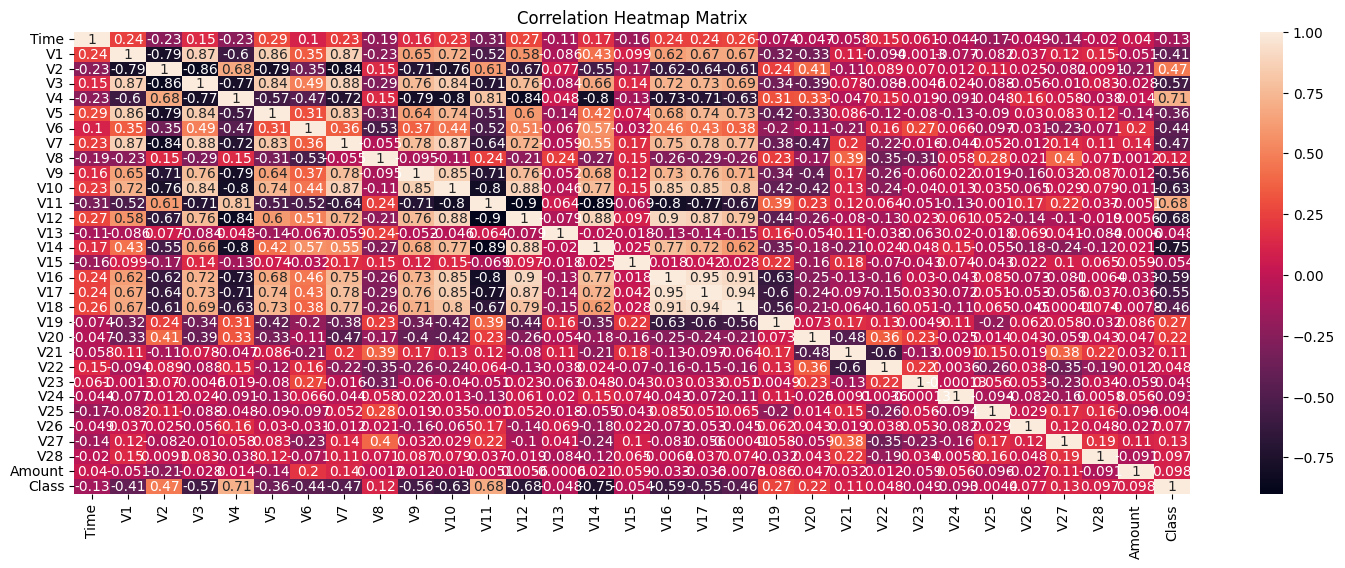

In [2664]:
#### get the graphical representation for the correlation for each numerical column with respect to other in the dataset

plt.figure(figsize=(18,6))
sns.heatmap(df_new.corr(), annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts about the graphical distributions for each numerical distributions with respect to the other in the dataset.

#### Step 6: Divide the dataset into normal and fraud transactions

In [2665]:
normal_df = df_new[df_new['Class']==0]

fraud_df  = df_new[df_new['Class']==1]

In [2666]:
normal_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
122207,76475.0,-1.004046,1.053270,1.093808,-0.591014,0.516087,-0.415980,0.476134,0.305124,-0.844857,...,-0.198036,-0.798085,-0.105299,-0.624258,-0.033219,-0.054535,-0.066880,0.004584,14.95,0
147150,88181.0,-0.422831,0.239428,1.512375,-1.075881,-0.809157,-0.089498,0.838381,-0.463100,-0.698558,...,-0.568205,-0.860065,-0.002557,-0.079295,-0.594139,-0.644110,-0.140223,-0.106076,123.75,0
132194,79893.0,-0.138855,-0.976921,0.883736,-3.393556,1.142488,3.914621,-1.119220,0.869570,-1.539373,...,-0.228985,-0.147826,-0.093426,0.977747,-0.269920,-0.413884,0.018587,-0.078387,20.00,0
259649,159214.0,0.256621,0.223809,0.975735,-0.220988,-0.270464,0.568080,-0.394989,-0.637367,0.416232,...,1.080174,0.763228,-0.220929,0.824970,0.789579,-0.064883,0.223809,0.257101,39.95,0
120126,75718.0,-1.438013,1.298178,0.909734,-0.495798,0.255640,-0.766527,0.449792,0.361424,-0.492433,...,-0.141175,-0.479615,0.105791,0.038759,-0.299486,-0.087374,-0.033205,0.108152,4.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273800,165706.0,2.341158,-1.140193,-1.431234,-1.446218,-0.959278,-1.328559,-0.580484,-0.525896,-1.617138,...,0.204313,1.250873,-0.096074,0.132532,0.408741,0.286812,-0.011742,-0.067825,13.99,0
9384,13744.0,-0.300059,0.364418,1.611098,-1.056658,0.652460,0.112808,0.338364,-0.154589,1.126379,...,-0.051844,0.166848,-0.294988,-0.818076,0.005634,0.907665,-0.267201,-0.249516,20.33,0
38205,39293.0,0.813744,-0.617420,1.782595,1.696710,-1.515473,0.350754,-0.893978,0.316722,1.186037,...,0.305272,0.919456,-0.114790,0.653273,0.272301,-0.189475,0.091363,0.064843,125.53,0
74642,55681.0,-1.833329,0.046103,2.151713,-0.431903,-0.762017,-0.388451,-0.215207,0.714157,-0.162439,...,0.310683,0.559447,-0.071901,0.598248,0.370825,0.617409,0.112006,-0.033303,101.16,0


In [2667]:
fraud_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


#### OBSERVATIONS:

1.  The dataset is divided into normal and fraud transactions.

2.  This is because the OneClassSVM is only trained on the normal data only as it learns all the features and behaviour of the normal data only.

#### Step 7: Divide the normal and fraud transactions into input and output values

In [2668]:
#### define the normal data

X_normal = normal_df.drop(columns='Class')

In [2669]:
X_normal

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
122207,76475.0,-1.004046,1.053270,1.093808,-0.591014,0.516087,-0.415980,0.476134,0.305124,-0.844857,...,0.031343,-0.198036,-0.798085,-0.105299,-0.624258,-0.033219,-0.054535,-0.066880,0.004584,14.95
147150,88181.0,-0.422831,0.239428,1.512375,-1.075881,-0.809157,-0.089498,0.838381,-0.463100,-0.698558,...,-0.469495,-0.568205,-0.860065,-0.002557,-0.079295,-0.594139,-0.644110,-0.140223,-0.106076,123.75
132194,79893.0,-0.138855,-0.976921,0.883736,-3.393556,1.142488,3.914621,-1.119220,0.869570,-1.539373,...,-0.153597,-0.228985,-0.147826,-0.093426,0.977747,-0.269920,-0.413884,0.018587,-0.078387,20.00
259649,159214.0,0.256621,0.223809,0.975735,-0.220988,-0.270464,0.568080,-0.394989,-0.637367,0.416232,...,-0.084076,1.080174,0.763228,-0.220929,0.824970,0.789579,-0.064883,0.223809,0.257101,39.95
120126,75718.0,-1.438013,1.298178,0.909734,-0.495798,0.255640,-0.766527,0.449792,0.361424,-0.492433,...,-0.160198,-0.141175,-0.479615,0.105791,0.038759,-0.299486,-0.087374,-0.033205,0.108152,4.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273800,165706.0,2.341158,-1.140193,-1.431234,-1.446218,-0.959278,-1.328559,-0.580484,-0.525896,-1.617138,...,-0.398666,0.204313,1.250873,-0.096074,0.132532,0.408741,0.286812,-0.011742,-0.067825,13.99
9384,13744.0,-0.300059,0.364418,1.611098,-1.056658,0.652460,0.112808,0.338364,-0.154589,1.126379,...,0.108753,-0.051844,0.166848,-0.294988,-0.818076,0.005634,0.907665,-0.267201,-0.249516,20.33
38205,39293.0,0.813744,-0.617420,1.782595,1.696710,-1.515473,0.350754,-0.893978,0.316722,1.186037,...,0.047077,0.305272,0.919456,-0.114790,0.653273,0.272301,-0.189475,0.091363,0.064843,125.53
74642,55681.0,-1.833329,0.046103,2.151713,-0.431903,-0.762017,-0.388451,-0.215207,0.714157,-0.162439,...,0.388125,0.310683,0.559447,-0.071901,0.598248,0.370825,0.617409,0.112006,-0.033303,101.16


#### OBSERVATIONS:

1.  X_normal is created as OneClassSVM is exclusively trained on the normal data only.

2.  It only learns the patterns of the normal data.

In [2670]:
#### Define the fraud data

X_fraud = fraud_df.drop(columns='Class')

In [2671]:
X_fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,-0.171608,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,0.009061,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00


In [2672]:
Y_fraud = fraud_df['Class']

In [2673]:
Y_fraud

541       1
623       1
4920      1
6108      1
6329      1
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 473, dtype: int64

#### OBSERVATIONS:

1.  Here initially we have data for normal and fraud transactions.

2.  OneClassSVM is exclusively trained on the normal data.

    (a.)    So Input data for normal transactions is used for normal data only (X_normal) with no target.

3.  Then as fraud transactions has no relation with training data,

    (a.)    So this fraud transactions is divided into input and output.

#### Step 8: Divide the dataset into training and testing data

In [2674]:
X_train, X_test = train_test_split(
    X_normal                    ,
    test_size     =       0.2   ,
    random_state  =       42
)

In [2675]:
X_train

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
191083,129099.0,-1.513345,1.123673,-3.460657,0.060873,0.425356,-1.350731,0.981516,0.554167,-0.527120,...,-0.729735,0.552743,1.819218,0.284785,0.699722,-0.928957,-0.436078,0.131113,-0.195169,66.46
211822,138585.0,-3.155926,-1.214814,0.200794,-2.231808,0.821859,1.232172,-1.254117,1.559717,-1.077663,...,0.141150,-0.120095,-0.671138,-0.539035,-0.927975,0.307694,-0.439993,0.415995,-0.397360,88.14
38407,39384.0,0.783986,-0.949831,1.051646,0.423050,-1.303123,-0.021012,-0.435236,0.090402,1.069453,...,0.298669,-0.064704,-0.289561,-0.021743,0.512566,-0.029031,0.929727,-0.048406,0.048168,195.80
202047,134148.0,0.061374,0.938905,0.252841,-0.630941,0.559457,-1.018138,1.070860,-0.250626,-0.173961,...,0.020757,-0.260881,-0.522477,0.036042,-0.091809,-0.439134,0.144386,0.253698,0.097694,1.78
178152,123500.0,2.053434,0.539174,-2.609758,1.319990,1.414113,-0.538761,0.739645,-0.347315,0.026051,...,-0.114792,-0.065394,0.039286,-0.100117,-0.071839,0.600945,-0.483863,0.001621,-0.024792,21.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184432,126241.0,1.967561,-1.212796,0.005362,-0.465616,-1.415820,0.061468,-1.329188,0.146808,0.046212,...,-0.442374,-0.255835,-0.246727,0.300866,-0.341804,-0.706497,0.481806,0.002202,-0.036923,59.63
178638,123713.0,-1.195804,-0.257156,0.237545,-2.897071,1.398154,-1.497629,1.078211,-0.134459,0.434833,...,0.053342,0.080830,0.010164,-0.479856,-0.477132,1.290695,-0.078257,-0.082718,0.021433,44.95
223277,143321.0,-2.041043,-0.032668,-1.238600,-0.180415,1.250018,-0.430283,1.014012,0.180763,-0.005577,...,-0.163774,-0.055556,0.415280,0.809613,-0.029335,0.267999,0.603938,0.010706,0.431537,135.00
3269,2819.0,-1.199752,-0.820796,0.778836,1.687205,1.887818,1.124627,-0.231829,0.621685,-0.798526,...,0.516898,0.470337,1.167774,0.486281,-0.982305,-0.798267,-0.084967,0.232419,0.213574,106.07


In [2676]:
X_test

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
195157,130925.0,-0.261988,1.075276,0.534878,-0.035774,0.434306,-0.857447,0.989392,-0.275622,-0.351470,...,0.160524,-0.210605,-0.393160,0.001862,0.006631,-0.660936,0.309352,0.250160,0.238880,8.78
80273,58409.0,1.083319,0.106537,0.234829,0.988555,-0.107632,-0.169206,0.054852,0.071070,-0.209056,...,-0.117965,0.124320,0.291516,-0.110275,0.018558,0.553808,-0.318450,0.015805,0.012408,43.06
266044,162166.0,-2.214548,-0.622397,0.313210,-0.497098,2.105973,-1.478035,-0.159904,-0.155619,0.208905,...,-0.820440,-0.399510,-0.605301,-0.562737,-0.340757,-0.569232,0.136877,0.005324,0.439709,4.45
36734,38667.0,1.179743,-1.164141,1.015352,-0.405885,-1.850985,-0.503236,-1.136412,0.074776,0.133414,...,0.158108,0.344607,0.785058,-0.164374,0.411598,0.369617,-0.051243,0.022254,0.038167,101.37
197151,131870.0,-5.372889,-2.898696,-0.732046,-0.226599,2.940701,0.535855,1.980516,-1.375468,2.012514,...,-3.920390,-1.729329,0.611861,1.923755,-1.642735,0.561185,0.029707,-0.287005,-1.881827,138.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124305,77250.0,1.176121,-1.549544,0.385788,-1.063133,-1.562251,-0.227279,-0.858840,-0.086094,-1.532157,...,-0.078414,-0.284266,-0.547030,-0.035217,0.061432,0.294401,-0.254867,0.032354,0.041754,156.56
74923,55814.0,0.986866,-1.232077,0.020012,-0.985952,-0.944489,-0.061102,-0.417647,-0.005032,-1.071534,...,-0.068311,-0.221571,-0.569379,-0.105691,-0.232161,0.001352,1.415867,-0.106669,0.018894,195.00
200936,133647.0,-0.521280,1.079176,-0.639399,0.244339,1.046164,-0.625651,0.996185,0.298648,-0.846303,...,-0.335779,0.262688,0.665376,-0.218452,-0.482413,-0.217983,-0.618632,0.075571,0.107579,14.14
66859,52250.0,0.798465,-1.333414,0.475241,-1.978915,-1.121443,0.237595,-0.629393,0.265090,2.141335,...,0.242321,0.369084,1.022170,-0.276451,-0.202333,0.445319,-0.619162,0.102080,0.047311,187.99


#### OBSERVATIONS:

1.  OneClasSVM is exclusively trained on the normal data, so it takes the normal data as the input.

2.  Here the test size is 20 % 

3.  After performing the train_test_split operation, X_train and X_test are only produced as OneClassSVM is an unsupervised anamoly based machine learning algorithm

4. OneClassSVM does not produced any labels or the target variables during the model training due to its unsupervised based nature.

#### Step 9: Perform Feature Scaling on the inputs

In [2677]:
#### Perform Feature Scaling

from    sklearn.preprocessing   import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [2678]:
X_train_scaled

array([[ 0.73028538, -0.64037165,  0.60204842, ...,  0.32823997,
        -0.55801713, -0.0479758 ],
       [ 0.93573708, -1.45661126, -0.98992409, ...,  0.92198439,
        -1.14492742,  0.05896784],
       [-1.21279903,  0.50122924, -0.8095312 , ..., -0.04590962,
         0.14833291,  0.59003577],
       ...,
       [ 1.03831132, -0.90259792, -0.18515405, ...,  0.07729154,
         1.26115999,  0.29012001],
       [-2.00473886, -0.48453983, -0.7216885 , ...,  0.53938031,
         0.62846616,  0.14741339],
       [-1.3444172 , -0.32789462, -0.02590502, ...,  0.52818816,
         0.206891  , -0.34128157]], shape=(393, 30))

In [2679]:
X_test_scaled

array([[ 0.76983364, -0.01854156,  0.56910131, ...,  0.57635525,
         0.70192402, -0.33250114],
       [-0.80074775,  0.64997541, -0.09038725, ...,  0.0879182 ,
         0.04452934, -0.1634039 ],
       [ 1.44646409, -0.98881724, -0.58662372, ...,  0.0660728 ,
         1.2848811 , -0.35386027],
       ...,
       [ 0.82878784, -0.14739003,  0.57175621, ...,  0.2124814 ,
         0.32078956, -0.3060612 ],
       [-0.93414191,  0.50842415, -1.0706634 , ...,  0.26772933,
         0.14584567,  0.5515104 ],
       [ 0.57471301,  1.12449947, -0.98030259, ...,  0.01131461,
        -0.15890655, -0.07392246]], shape=(99, 30))

In [2680]:
X_fraud_scaled = sc.transform(X_fraud)

In [2681]:
X_fraud_scaled

array([[-2.05700061, -1.03735589,  1.16594354, ...,  0.59925029,
        -0.40738295, -0.37581134],
       [-2.05557115, -1.40076405, -2.3123156 , ..., -0.47184708,
         0.11232731,  2.23365301],
       [-1.96915409, -1.0329447 ,  1.03472878, ...,  0.13743996,
        -0.43569333,  0.80772133],
       ...,
       [ 1.60207978, -0.22434511,  0.60388191, ...,  0.85761022,
         0.57269691,  0.00840639],
       [ 1.6153997 , -1.43569339,  0.23592427, ...,  1.89921639,
        -0.72791849,  0.83273075],
       [ 1.62367321,  1.10150949, -0.05502898, ...,  0.06120401,
        -0.03592541, -0.1660183 ]], shape=(473, 30))

#### OBSERVATIONS:

1.  OneClassSVM is exclusively trained on the normal data. So the model training is done on the input normal data.

2.  Then only input training and testing data is produced as OneClassSVM is an unsupervised machine learning based algorithm as it does not produce any labels during model training

3.  fit_transform is only used for training as it learns all the mean and standard deviation from the learning data.

4.  transform is used for testing as it used the mean and std from the training data.

5.  X_fraud_scaled uses transform only as it has its own mean and std and only uses it for testing purpose otherwise data leakage is caused.

#### Step 10: Train One Class SVM

In [2682]:
#### Create an object for One Class SVM

from sklearn.svm    import  OneClassSVM

#### Create an object for OneClassSVM

oneclassobj = OneClassSVM(
    kernel          =           'rbf'                   ,
    gamma           =           'auto'                  ,
    nu              =            0.01        
)


#### using the object of OneClassSVM, train the model

oneclassobj.fit(X_train_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


#### OBSERVATIONS:

1.  The object of OneClassSVM is created with the help of the following parameters :----------------

    (a.)    kernel  =   'rbf'       =   Radial Basis Function   .   It deals with the non linear decision boundary.

    (b.)    gamma   =   'auto'      It determines how the influence of the single data point influence others.

    (c.)    nu      =   0.01        Expected anamoly percentage

2. Using the object of OneClassSVM, this model is training with the input training data only

    (a.)    This is because OneClassSVM is an unsupervised anamoly based algorithm where the model does not need any result during model training.

#### Step 11: Predict the Transactions

In [2683]:
#### Predict the normal transactions

Y_pred_normal = oneclassobj.predict(X_test_scaled)

In [2684]:
Y_pred_normal

array([ 1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,
        1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1])

In [2685]:
#### Predict the fraud transactions

Y_pred_fraud = oneclassobj.predict(X_fraud_scaled)

In [2686]:
Y_pred_fraud

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1, -1,
       -1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1, -1, -1, -1, -1, -1,  1,
       -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1,  1, -1,  1, -1,  1, -1,
       -1, -1,  1,  1, -1

#### OBSERVATIONS:

1.  After performing OneClassSVM operations on the normal and fraud transactions dataset, we see that

    (a.)    1 ==================================>      Normal Transactions

    (b.)    -1 =================================>      Fraud  Transactions

#### Step 12:   Convert the Prediction Labels for Model Evaluation

In [2687]:
#### Create the labels for normal transaction

Y_test_normal = np.ones(len(Y_pred_normal),dtype='int')

In [2688]:
Y_pred_normal

array([ 1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,
        1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1])

In [2689]:
Y_test_normal

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [2690]:
#### Create the labels for fraud transactions

Y_test_fraud = -np.ones(len(Y_pred_fraud),dtype='int')

In [2691]:
Y_pred_fraud

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1, -1,
       -1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1, -1, -1, -1, -1, -1,  1,
       -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1,  1, -1,  1, -1,  1, -1,
       -1, -1,  1,  1, -1

In [2692]:
Y_test_fraud

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1

#### OBSERVATIONS:

1.  Here we are converting the predictions into true labels for model evaluation.

2.  OneClassSVM produces

    (a.)    1   ======================>         Normal  Transactions

    (b.)    -1  ======================>         Fraud   Transactions

3.  With respect to these transactions, we need to create the matching labels for this.

#### Step 13: Combine the results

In [2693]:
Y_test_fraud.shape

(473,)

In [2694]:
Y_test_normal.shape

(99,)

In [2695]:
#### Combine all the test values in one array

true = np.concatenate([Y_test_fraud, Y_test_normal])

In [2696]:
true

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1

In [2697]:
true.shape

(572,)

In [2698]:
Y_pred_normal

array([ 1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,
        1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1])

In [2699]:
Y_pred_fraud

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1, -1,
       -1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1, -1, -1, -1, -1, -1,  1,
       -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1,  1, -1,  1, -1,  1, -1,
       -1, -1,  1,  1, -1

In [2700]:
Y_pred_normal.shape

(99,)

In [2701]:
Y_pred_fraud.shape

(473,)

In [2702]:
#### Combine all the predicted values in one array

pred = np.concatenate([Y_pred_normal, Y_pred_fraud])

In [2703]:
pred

array([ 1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,
        1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1

In [2704]:
pred.shape

(572,)

#### Step 14: Perform the Classification Evaluation Metrics

===================================Accuracy score========================================================
Accuracy score of the model is: 65.20979020979021
===================================Confusion Matrix========================================================


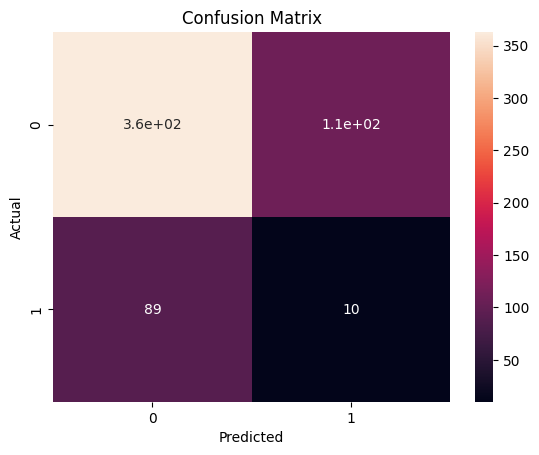

===================================Classification Report========================================================
Classification report of the model is:               precision    recall  f1-score   support

          -1       0.80      0.77      0.78       473
           1       0.08      0.10      0.09        99

    accuracy                           0.65       572
   macro avg       0.44      0.43      0.44       572
weighted avg       0.68      0.65      0.66       572

===================================Precision  Score========================================================
Precision score of the model is: 0.08333333333333333
===================================Recall  Score========================================================
Recall score of the model is: 0.10101010101010101
===================================F1 Score========================================================
F1 score of the model is: 0.091324200913242


In [2705]:
print('===================================Accuracy score========================================================')
ac = accuracy_score(true, pred)*100.0
print("Accuracy score of the model is:", ac)

print('===================================Confusion Matrix========================================================')
cm = confusion_matrix(true, pred)
sns.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print('===================================Classification Report========================================================')
cr = classification_report(true,pred)
print("Classification report of the model is:", cr)


print('===================================Precision  Score========================================================')
pr = precision_score(true, pred)
print("Precision score of the model is:", pr)

print('===================================Recall  Score========================================================')
re = recall_score(true, pred)
print("Recall score of the model is:", re)


print('===================================F1 Score========================================================')
f1 = f1_score(true, pred)
print("F1 score of the model is:", f1)

#### OBSERVATIONS:

1.  The accuracy of OneClassSVM on the creditcard dataset is 65.2

2.  As the accuracy of the model is high, so it is working fine.

#### Step 15: Plot Prediction Distribution

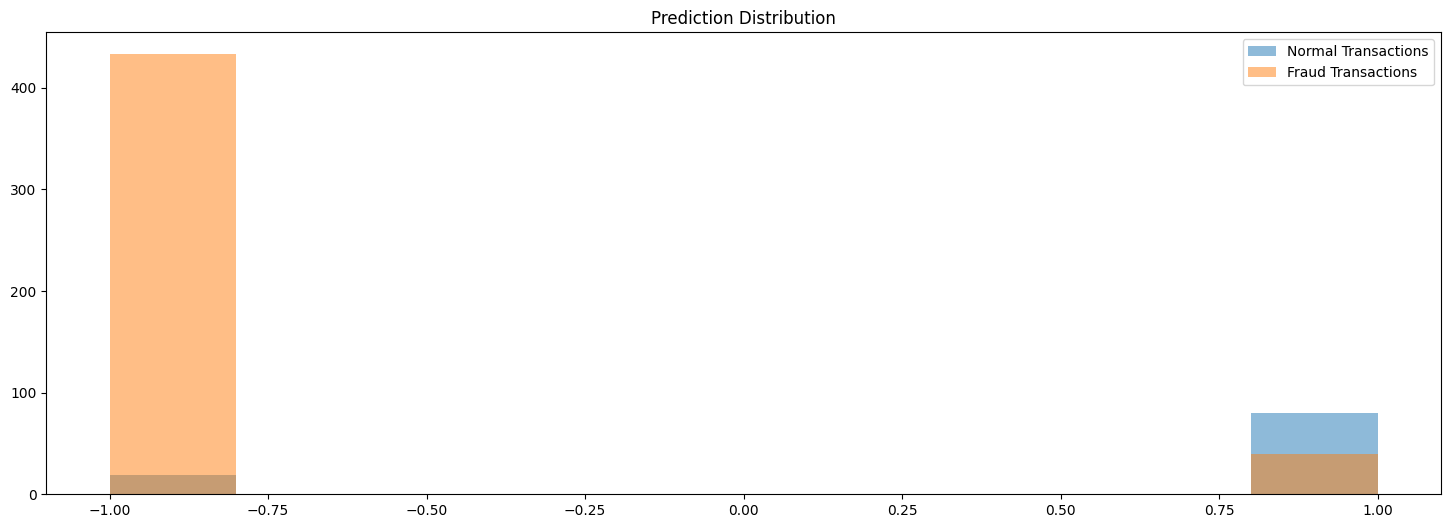

In [2706]:
plt.figure(figsize=(18,6))

#### Plot the distributions for the normal transactions

plt.hist(Y_pred_normal, alpha = 0.5, label = 'Normal Transactions')

#### Plot the distributions for the fraud transactions

plt.hist(Y_pred_fraud, alpha = 0.5, label = 'Fraud Transactions')

plt.legend()

plt.title("Prediction Distribution")

plt.show()

#### OBSERVATIONS:

1.  From the above graph, we can see that

    (a.)    The number of fraud transactions is much higher in number than the normal transactions.

#### Step 16: Anomaly Scores

In [2707]:
#### Anamoly scores

scores = oneclassobj.decision_function(X_fraud_scaled)

In [2708]:
scores

array([-0.12641286, -0.06443767, -0.13515147, -0.13994999, -0.13735304,
       -0.1399466 , -0.13994675, -0.13982649, -0.13981976, -0.13992076,
       -0.13992539, -0.1389235 , -0.13989414, -0.13989524, -0.13978658,
       -0.13994993, -0.1399499 , -0.1399493 , -0.13994926, -0.13994849,
       -0.1399485 , -0.13994999, -0.13994976, -0.13994977, -0.13988456,
       -0.13994999, -0.13980499, -0.13994999, -0.13994999, -0.13976744,
       -0.13994999, -0.13994999, -0.13972267, -0.13994999, -0.13994999,
       -0.13994999, -0.13994999, -0.13994999, -0.1398157 ,  0.01863718,
        0.01840249,  0.0002237 , -0.13994999, -0.13994999, -0.13994999,
       -0.13994999, -0.13994999, -0.13994999, -0.13994999, -0.13994999,
       -0.13994999, -0.13994999, -0.13994999, -0.13994999, -0.13994999,
       -0.13994999, -0.03094228, -0.13994999, -0.13994999, -0.13994999,
        0.01153469, -0.13994999, -0.13994999, -0.13994999, -0.13994999,
       -0.13994999, -0.13994999, -0.13994999, -0.13994999, -0.13

#### OBSERVATIONS:

#### Score Interpretation:

| Score    | Meaning    |
| -------- | ---------- |
| Positive | Normal     |
| Near 0   | Borderline |
| Negative | Anomaly    |

1.  From the above data , we can see that maximum of the scores are negative in nature.

2.  Lower the score, more anamolity in the data is there.
